In [1]:
# ── BLOCK 1: Import & Load ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"E:\NCI\Sem3\Thesis\implementation\data\creditcard_with_tiers.csv")

print("Loaded successfully!")
print(f"Shape: {df.shape}")

Loaded successfully!
Shape: (284807, 32)


In [2]:
# ── BLOCK 2: Risk Tier Analysis — The Core Argument ──

# Calculate stats per risk tier
tier_order = ['Low', 'Medium', 'High', 'Critical']
tier_stats = []

for tier in tier_order:
    tier_data = df[df['Risk_Tier'] == tier]
    total = len(tier_data)
    frauds = len(tier_data[tier_data['Class'] == 1])
    fraud_rate = (frauds / total) * 100
    avg_amount = tier_data['Amount'].mean()
    total_fraud_value = tier_data[tier_data['Class']==1]['Amount'].sum()
    
    tier_stats.append({
        'Tier': tier,
        'Total': total,
        'Frauds': frauds,
        'Fraud_Rate': fraud_rate,
        'Avg_Amount': avg_amount,
        'Total_Fraud_Value': total_fraud_value
    })

stats_df = pd.DataFrame(tier_stats)
print("=== RISK TIER ANALYSIS ===")
print(stats_df.to_string(index=False))

=== RISK TIER ANALYSIS ===
    Tier  Total  Frauds  Fraud_Rate  Avg_Amount  Total_Fraud_Value
     Low 142643     271    0.189985    7.334921             808.34
  Medium  70898      47    0.066292   43.991656            2006.31
    High  62124     139    0.223746  183.209885           26118.42
Critical   9142      35    0.382848 1051.811808           31194.90


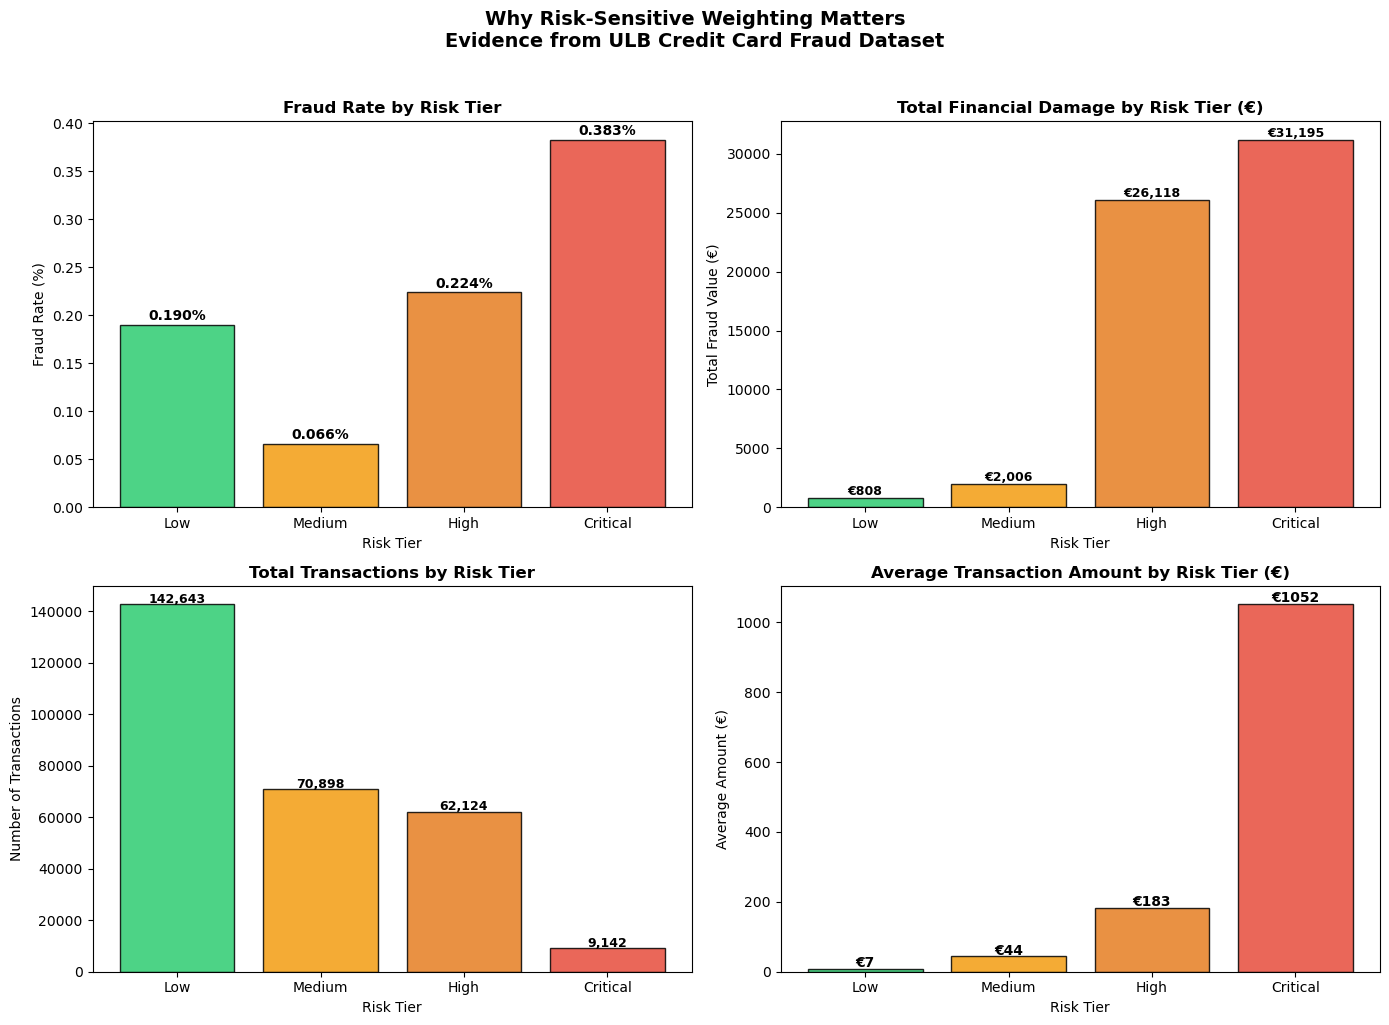

✅ Chart saved!


In [3]:
# ── BLOCK 3: The Killer Visualisation ──

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Why Risk-Sensitive Weighting Matters\nEvidence from ULB Credit Card Fraud Dataset', 
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Chart 1 — Fraud Rate by Tier
axes[0,0].bar(stats_df['Tier'], stats_df['Fraud_Rate'], 
              color=colors, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Fraud Rate by Risk Tier', fontweight='bold')
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].set_xlabel('Risk Tier')
for i, v in enumerate(stats_df['Fraud_Rate']):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}%', ha='center', 
                   fontweight='bold', fontsize=10)

# Chart 2 — Total Fraud Value by Tier
axes[0,1].bar(stats_df['Tier'], stats_df['Total_Fraud_Value'], 
              color=colors, edgecolor='black', alpha=0.85)
axes[0,1].set_title('Total Financial Damage by Risk Tier (€)', fontweight='bold')
axes[0,1].set_ylabel('Total Fraud Value (€)')
axes[0,1].set_xlabel('Risk Tier')
for i, v in enumerate(stats_df['Total_Fraud_Value']):
    axes[0,1].text(i, v + 200, f'€{v:,.0f}', ha='center', 
                   fontweight='bold', fontsize=9)

# Chart 3 — Number of Transactions per Tier
axes[1,0].bar(stats_df['Tier'], stats_df['Total'], 
              color=colors, edgecolor='black', alpha=0.85)
axes[1,0].set_title('Total Transactions by Risk Tier', fontweight='bold')
axes[1,0].set_ylabel('Number of Transactions')
axes[1,0].set_xlabel('Risk Tier')
for i, v in enumerate(stats_df['Total']):
    axes[1,0].text(i, v + 500, f'{v:,}', ha='center', 
                   fontweight='bold', fontsize=9)

# Chart 4 — Average Transaction Amount per Tier
axes[1,1].bar(stats_df['Tier'], stats_df['Avg_Amount'], 
              color=colors, edgecolor='black', alpha=0.85)
axes[1,1].set_title('Average Transaction Amount by Risk Tier (€)', fontweight='bold')
axes[1,1].set_ylabel('Average Amount (€)')
axes[1,1].set_xlabel('Risk Tier')
for i, v in enumerate(stats_df['Avg_Amount']):
    axes[1,1].text(i, v + 5, f'€{v:.0f}', ha='center', 
                   fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(r"E:\NCI\Sem3\Thesis\implementation\results\risk_tier_analysis.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [5]:
# ── BLOCK 4: Save Risk Tier Stats ──

stats_df.to_csv(r"E:\NCI\Sem3\Thesis\implementation\results\risk_tier_stats.csv", 
                index=False)
